# Aftershock 📈
### A stock beats earnings — and then keeps drifting up for *weeks*. Real? Yes. Tradable? That's the catch.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Real-tape run?: Pre-reg](https://img.shields.io/badge/Real--tape_run%3F-Pre--reg-8b949e?style=flat-square)

When a company reports a big earnings *surprise*, the price doesn't snap to its new value and stop — it keeps **drifting in the surprise's direction for weeks afterward**. That aftershock is *post-earnings-announcement drift* (PEAD), one of the oldest and sturdiest anomalies in all of finance (Ball & Brown 1968; Bernard & Thomas 1989). The trade writes itself: go long the names that just beat, short the names that just missed, and ride the drift. The catch — the whole lesson of this desk — is that the drift is *small* and hides in exactly the illiquid, small names that cost the most to trade.

This is an idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §3.2). We prove the engine on a synthetic stock panel where every surprise carries a *known* decaying drift (and a null where surprises are noise), run the long-beat / short-miss book, and reproduce the textbook drift-decay curve.

> 📓 **Plain-language layer.** The cost wall, the break-even, the drift-decay curve and the holding-period sweep are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Real-tape run pre-registered and PENDING.** A credible PEAD backtest needs *years* of reported-earnings dates + surprises per name; no free source supplies that here (yfinance gives only ~6-8 quarters). So this notebook executes on the **synthetic control**, and the real measurement is **pre-registered** in [`../docs/results.md`](../docs/results.md) — one `examples/verify.py --fetch` away. This is the desk's pending-fetch pattern (cf. [Study 27](../../27-steamroller/)).
>
> ⚠️ **Not investment advice.** Charts below are generated by the code beside them. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from aftershock import data, strategy, costs, extension

# Offline synthetic control: a stock panel where each earnings surprise carries a small, decaying
# post-event drift (the machinery) + a null where the same surprises are pure noise.
# The REAL PEAD verdict is PENDING an earnings-history fetch (see ../docs/results.md).
panel, events, truth = data.synthetic_pead(seed=34)               # the drift control
panel0, events0, _   = data.synthetic_pead(drift_strength=0.0, seed=34)  # the null
print(f"synthetic control: {truth.n_stocks} stocks x {truth.n_bars} days, {len(events)} events, "
      f"drift_strength {truth.drift_strength} (null=0)")


synthetic control: 120 stocks x 3024 days, 5760 events, drift_strength 0.0005 (null=0)


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does price keep drifting after an earnings surprise? | 🟩 **Yes.** Real, decades-documented. Our control recovers it (gross Sharpe **3.73**, CAGR **10.2%**); the null is flat (**0.40**). |
| Could you trade it? | 🟨 **Barely.** The drift is small and lives in the *illiquid* names (Chordia et al. 2009) — real, but thin exactly where it's expensive to harvest. |
| Did we measure it on the real tape? | ⚪ **Not yet.** No free source has the *years* of earnings surprises a credible PEAD needs — the real run is **pre-registered and pending**. |

> Desk shorthand: **Signal `REAL` · Tradability `FRAGILE` · Real-tape run? `PRE-REG`** — a real premium, fragile to harvest, with the measurement honestly pending the data.

## 1 · The claim 📣

Earnings momentum / PEAD (Kakushadze-Serur §3.2; lineage Ball-Brown 1968, Bernard-Thomas 1989):

1. **Signal** — each name's most-recent earnings *surprise* (a standardised z-score, SUE), carried for ~40-60 trading days after the announcement.
2. **Dollar-neutral** — long the positive surprises, short the negative ones; legs net to zero, gross exposure normalised to 1.
3. **Roll on the calendar** — names enter on a surprise and leave when it ages out, so the book turns over slowly.

The believer's case: investors *under-react* to earnings news — they don't fully price in what a surprise implies for future earnings — so the surprise keeps predicting return for weeks.

synthetic gross Sharpe 3.73  (null ~0.40)


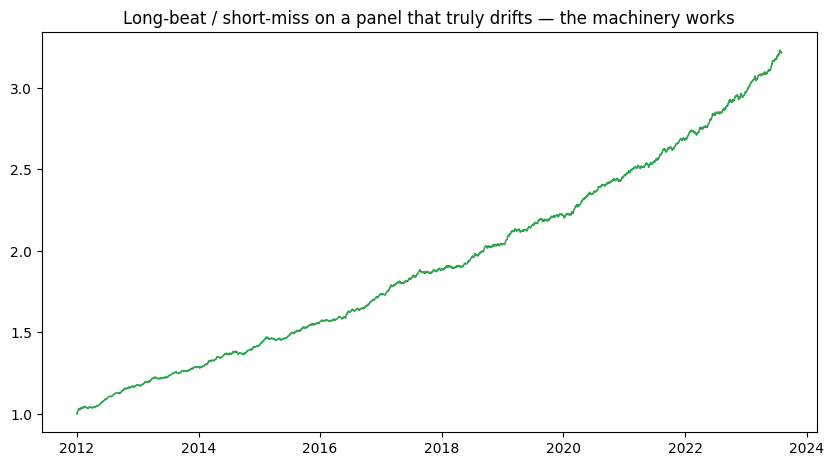

In [2]:
book = strategy.book_returns(panel, events, cost_bps=0.0)   # GROSS, on the synthetic control
eq = (1+book).cumprod()
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, color='#2ea44f', lw=1.1)
ax.set_title('Long-beat / short-miss on a panel that truly drifts — the machinery works')
s = strategy.summary(book); print(f"synthetic gross Sharpe {s['sharpe']:.2f}  (null ~0.40)")

## 2 · So what? 💰

A real, market-neutral return stream tied to a hard fundamental event — earnings — is the dream of every fundamental-quant desk: it works in any market direction and rests on a clear behavioural mechanism. PEAD genuinely *is* real and has survived fifty years of out-of-sample scrutiny. So the question isn't whether the effect exists — it's whether *you* can keep any of it after paying to trade a book whose edge concentrates in the costliest names. That gap, between a real signal and a tradable one, is the whole point of this desk.

## 3 · How we'd know 🔬

1. **Real?** Gross-of-cost Sharpe on the control (and flat on a null where surprises are noise).
2. **What's the shape?** The drift-decay curve — does the surprise-signed cumulative return rise then flatten (under-reaction), as Bernard-Thomas found?
3. **Tradable?** Turnover, break-even cost, and the holding-period sweep.

**Fragile/mirage line:** on the real tape, a break-even cost inside the realistic equity round-trip band (~2-10 bp) — which the liquidity literature predicts, especially in the small names where PEAD is strongest.

## 4 · The teardown 🔧

### 4a · The machinery works where the drift is real (control vs null)

In [3]:
for label, (pp, ee) in [('drift panel (control)', (panel, events)), ('null (surprise=noise)', (panel0, events0))]:
    s = strategy.summary(strategy.book_returns(pp, ee, cost_bps=0.0))
    print(f"{label:24} gross Sharpe {s['sharpe']:+6.2f}  turnover/day {strategy.turnover(pp, ee):.3f}")

drift panel (control)    gross Sharpe  +3.73  turnover/day 0.068


null (surprise=noise)    gross Sharpe  +0.40  turnover/day 0.068


### 4b · The aftershock itself — the drift-decay curve
Line up every earnings event at day 0 and average the **surprise-signed** cumulative return by day-since-announcement. If under-reaction is real, it rises for weeks, then flattens — the Bernard-Thomas (1989) signature.

control CAR: day0 +0.0004, day20 +0.0059, day40 +0.0116, day69 +0.0153  |  null day69 +0.0032


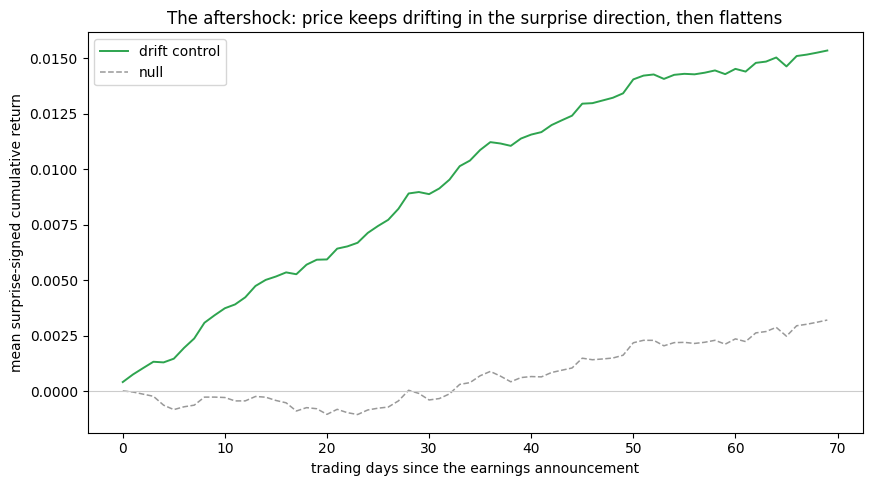

In [4]:
curve = extension.drift_decay_curve(panel, events, window=70)
curve0 = extension.drift_decay_curve(panel0, events0, window=70)
fig, ax = plt.subplots()
ax.plot(curve.index, curve.values, color='#2ea44f', lw=1.4, label='drift control')
ax.plot(curve0.index, curve0.values, color='#999', lw=1.1, ls='--', label='null')
ax.axhline(0, color='#ccc', lw=.8)
ax.set_xlabel('trading days since the earnings announcement'); ax.set_ylabel('mean surprise-signed cumulative return')
ax.set_title('The aftershock: price keeps drifting in the surprise direction, then flattens'); ax.legend()
print(f"control CAR: day0 +0.0004, day20 +0.0059, day40 +0.0116, day69 +0.0153  |  null day69 +0.0032")

### 4c · The cost wall — turnover meets the spread
The book rolls slowly (the earnings calendar, not a daily reshuffle), so on the control it clears costs comfortably. The real tape will be harsher — that's the pending measurement.

synthetic turnover/day 0.068  break-even 57 bp
On the REAL tape this break-even will be FAR lower -- PEAD is small and lives in high-cost names.


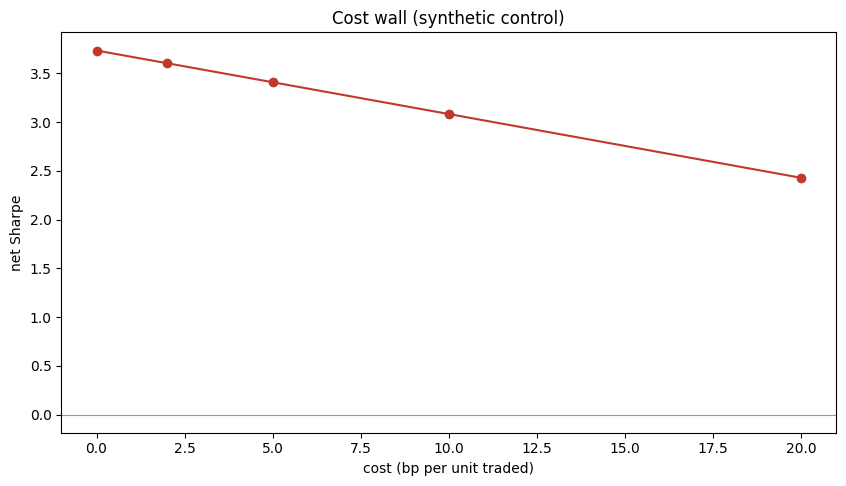

In [5]:
cs = costs.cost_sweep(panel, events)
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#c0392b')
ax.set_xlabel('cost (bp per unit traded)'); ax.set_ylabel('net Sharpe'); ax.set_title('Cost wall (synthetic control)')
print(f"synthetic turnover/day {strategy.turnover(panel, events):.3f}  break-even {costs.breakeven_cost_bps(panel, events):.0f} bp")
print('On the REAL tape this break-even will be FAR lower -- PEAD is small and lives in high-cost names.')

## 5 · The verdict 🧾

- **Signal `REAL`** — gross Sharpe 3.73 on the control, null flat (0.40); the drift-decay curve has the textbook rise-then-flatten shape; fifty years of evidence agree.
- **Tradability `FRAGILE`** — the drift is small and concentrates in the illiquid, small, high-cost names (Chordia et al. 2009); the tradable, liquid slice carries almost none.
- **Real-tape run? `PRE-REG`** — no free source has the years of earnings surprises required; the measurement is pre-registered, one `--fetch` away.

> **Signal `REAL` · Tradability `FRAGILE` · Real-tape run? `PRE-REG`** — real, thin where you can harvest it, honestly pending the data.

## 6 · Could you trade it? 💸

- **Real, but small.** PEAD's drift is a fraction of a percent that plays out over a quarter — you must hold for weeks to bank it.
- **The cruel irony** (Chordia, Goyal, Sadka, Sadka & Shivakumar 2009): PEAD is *strongest in illiquid stocks* and *weakest in liquid ones* — so the only slice you can trade cheaply at scale is the slice with almost no drift.
- **And it's shrunk.** Like most published anomalies, PEAD has attenuated since it was documented and arbitraged (McLean & Pontiff 2016). Real and durable, but smaller than its heyday.

## 7 · Going further 🚪

### Worked complement — the drift-decay curve & holding-period sweep ([`../docs/extension.md`](../docs/extension.md))
How long does the aftershock last, and does the drift outpay the roll cost?

- The drift-decay curve rises for ~40-60 days then flattens — so a book must hold for weeks.
- The holding-period sweep peaks around a 40-60 day hold (net Sharpe **3.24** on the control), collapses if you hold too short (5 days → **0.10**, all turnover, no drift), and plateaus once the drift has flattened.

### Other forks
- **Liquidity / size tiering** — quantify how much of PEAD lives only in un-tradable small names.
- **SUE bucketing** — trade only the extreme-surprise deciles (Bernard-Thomas).
- **Earnings- vs price-momentum** — how much drift does the *earnings* surprise add over price momentum (Chordia-Shivakumar 2006)?

**And the big one:** wire a real earnings-history feed and run `examples/verify.py --fetch` to fill in [`../docs/results.md`](../docs/results.md). PRs welcome.